# Parcial 2024 — RESUELTO

**Solución de referencia** generada y verificada por Claude (5/7/2026). Es el parcial más exigente de los cuatro: el Ej. 1 combina regresión + ARMA + predicción recursiva, y el Ej. 3 introduce espacio de estados.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astsadata as astsa
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.constrained_layout.use'] = True

def ccf(x, y, max_lag, ax=None, **kwargs):
    lags = np.arange(-max_lag, max_lag + 1)
    backwards = sm.tsa.ccf(x[::-1], y[::-1], adjusted=False)[max_lag::-1]
    forwards = sm.tsa.ccf(x, y, adjusted=False)[:max_lag + 1]
    ccf = np.r_[backwards[:-1], forwards]
    if ax is None:
        ax = plt.gca()
    ax.stem(lags, ccf, basefmt='k')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    conf_level = 1.96 / np.sqrt(x.shape[0])
    ax.fill_between(lags, conf_level, -conf_level, alpha=0.25)
    ax.set_xlabel('LAG')
    ax.set_ylabel('CCF')
    return ax

def periodogram(x, sampling_frequency=1):
    n = x.size
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0, round(n/2))/n * sampling_frequency
    plt.plot(f, P)
    plt.xlabel('Frequency')
    plt.ylabel('Power')

def spectrum(x, sampling_frequency=1, nfreq=10):
    n = x.size
    nfreq = np.minimum(nfreq, round(n/2))
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0, round(n/2))/n * sampling_frequency
    index = np.argsort(P)[::-1]
    return pd.DataFrame({'Frecuencia': f[index[0:nfreq]], 'Potencia': P[index[0:nfreq]]})

---
## Ejercicio 1 — `flu`: regresión con dummies + ARMA sobre residuos + predicción completa

Mortalidad por gripe en EEUU (mensual, 1968–1978). Train: hasta 1977; test: 1978. Se pide: (1) describir + ACF, (2) log, (3) regresión con tendencia y dummies mensuales relevantes, (4) ARMA sobre los residuos + MSE, (5) predicción completa 1979–1980 con `fit.append`, (6) predicción combinada en la escala original.

### 1.1 Descripción, tendencias, estacionalidad y ACF

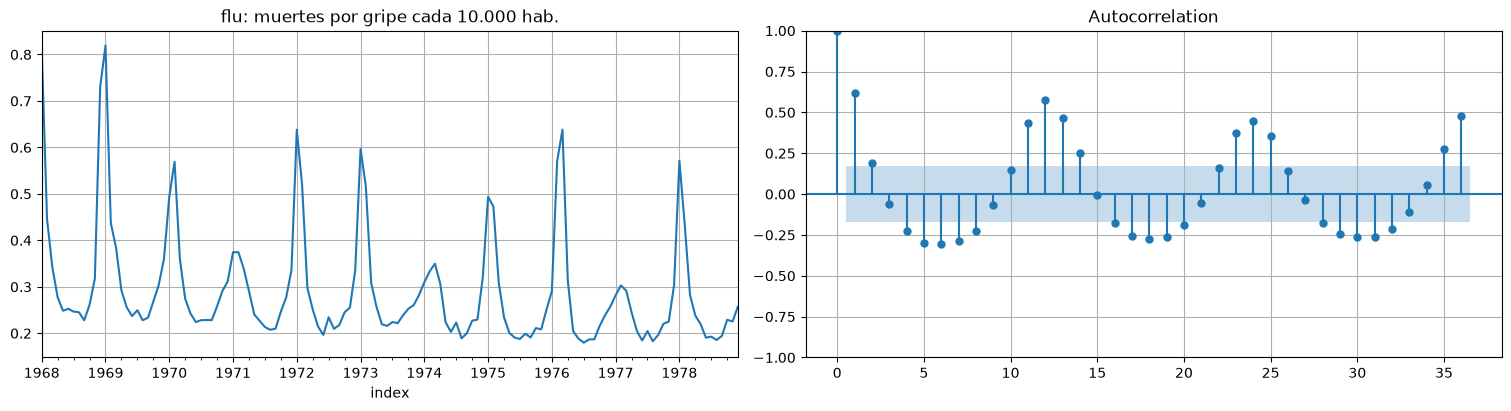

In [3]:
flu = astsa.flu.squeeze()
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
flu.plot(ax=axs[0], title='flu: muertes por gripe cada 10.000 hab.')
plot_acf(flu, lags=36, bartlett_confint=False, ax=axs[1]);

**💬 Discusión 1.1** — La serie presenta **estacionalidad anual muy marcada** (picos cada invierno) con intensidad variable entre años, y una **leve tendencia decreciente** en el nivel y en la altura de los picos. La ACF lo confirma: **onda de período 12** con correlaciones significativas que se repiten en los múltiplos de 12. La varianza no es constante (los picos dominan) → motiva el log.

### 1.2 Cambio de variable log

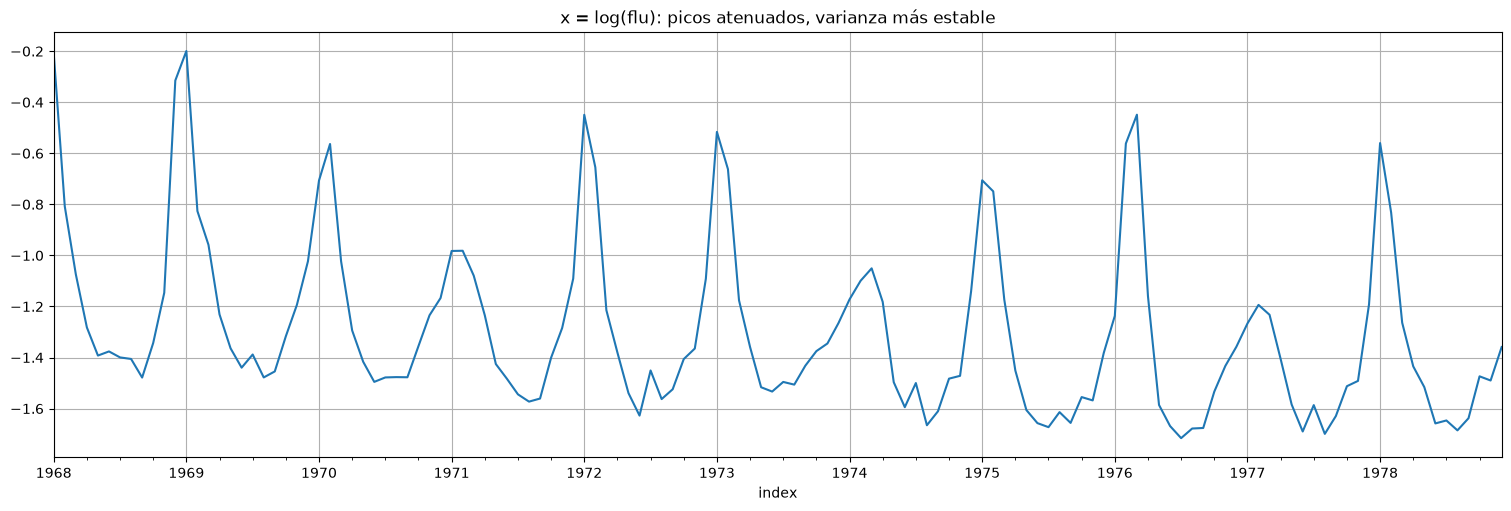

In [4]:
y = np.log(flu)
y.plot(title='x = log(flu): picos atenuados, varianza más estable');

### 1.3 Regresión con tendencia + dummies mensuales (solo las relevantes)

In [5]:
n = len(y)
k = 12   # test = año 1978
dfE = pd.DataFrame({'y': y.values, 't': np.arange(n), 'mes': y.index.month}, index=y.index)
dum = pd.get_dummies(dfE['mes'], prefix='m', drop_first=True).astype(int)   # m_2..m_12 (base: enero)
dfE = pd.concat([dfE, dum], axis=1)
df_tr, df_te = dfE.iloc[:-k], dfE.iloc[-k:]

cols = list(dum.columns)
fit1 = ols('y ~ t + ' + ' + '.join(cols), data=df_tr).fit()
print(fit1.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5934      0.056    -10.504      0.000      -0.705      -0.481
t             -0.0028      0.000     -6.488      0.000      -0.004      -0.002
m_2           -0.0628      0.073     -0.863      0.390      -0.207       0.082
m_3           -0.2930      0.073     -4.025      0.000      -0.437      -0.149
m_4           -0.5451      0.073     -7.487      0.000      -0.689      -0.401
m_5           -0.7371      0.073    -10.123      0.000      -0.881      -0.593
m_6           -0.7981      0.073    -10.959      0.000      -0.942      -0.654
m_7           -0.7619      0.073    -10.461      0.000      -0.906      -0.618
m_8           -0.8019      0.073    -11.006      0.000      -0.946      -0.657
m_9           -0.7831      0.073    -10.746      0.000      -0.928      -0.639
m_10          -0.6585      0.073     -9.033      0.0

Meses retenidos (vs. base enero): ['m_3', 'm_4', 'm_5', 'm_6', 'm_7', 'm_8', 'm_9', 'm_10', 'm_11', 'm_12']

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6247      0.043    -14.437      0.000      -0.710      -0.539
t             -0.0028      0.000     -6.501      0.000      -0.004      -0.002
m_3           -0.2616      0.063     -4.155      0.000      -0.386      -0.137
m_4           -0.5137      0.063     -8.157      0.000      -0.639      -0.389
m_5           -0.7057      0.063    -11.204      0.000      -0.831      -0.581
m_6           -0.7667      0.063    -12.170      0.000      -0.892      -0.642
m_7           -0.7305      0.063    -11.594      0.000      -0.855      -0.606
m_8           -0.7705      0.063    -12.224      0.000      -0.895      -0.646
m_9           -0.7517      0.063    -11.923      0.000      -0.877      -0.627
m_10          -0.6270 

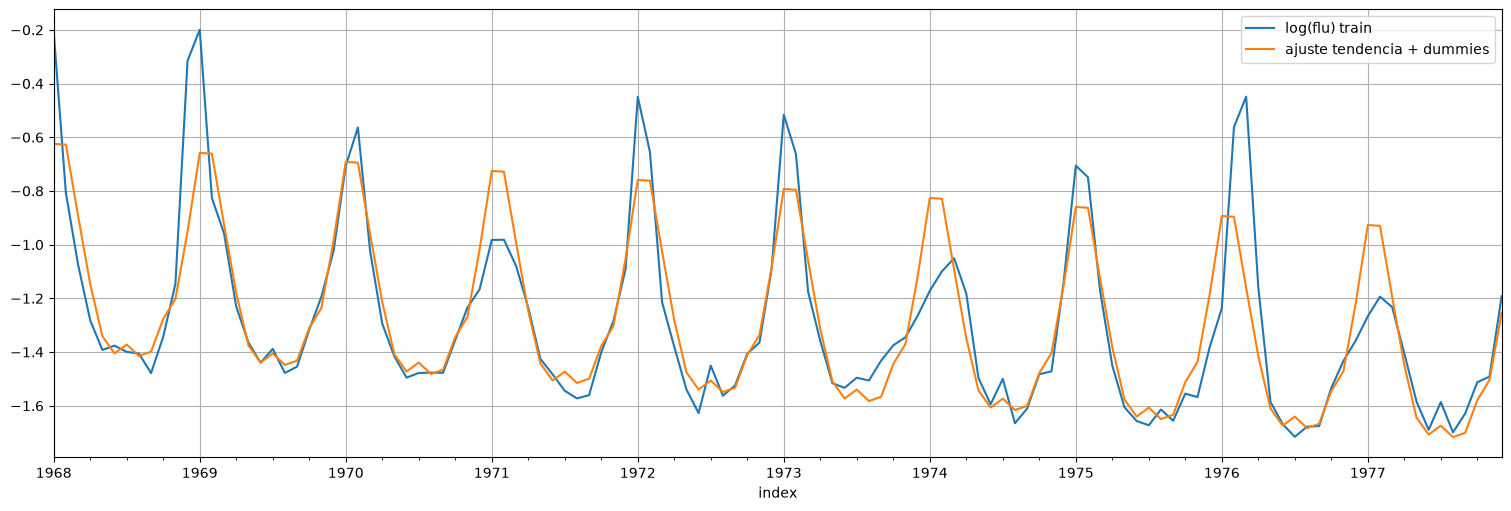

In [6]:
# Nos quedamos solo con las dummies significativas (p < 0.05) y reajustamos
keep = [c for c in cols if fit1.pvalues[c] < 0.05]
print('Meses retenidos (vs. base enero):', keep)

fit_reg = ols('y ~ t + ' + ' + '.join(keep), data=df_tr).fit()
print()
print(fit_reg.summary().tables[1])
print()
print(f'R2 = {fit_reg.rsquared:.3f} | AIC = {fit_reg.aic:.1f} (completo: {fit1.aic:.1f})')

ax = pd.Series(df_tr['y'].values, index=df_tr.index).plot(label='log(flu) train')
fit_reg.fittedvalues.plot(ax=ax, label='ajuste tendencia + dummies')
ax.legend();

**💬 Discusión 1.3** — Las dummies se interpretan **contra el mes base (enero, mes de pico)**: los meses de fin e inicio de invierno no se distinguen significativamente de enero, mientras que los meses cálidos tienen coeficientes negativos grandes y significativos. Retenemos la tendencia (negativa: la mortalidad baja año a año) y solo las dummies significativas — declarar esta selección es parte de la respuesta.

### 1.4 ARMA sobre los residuos + MSE

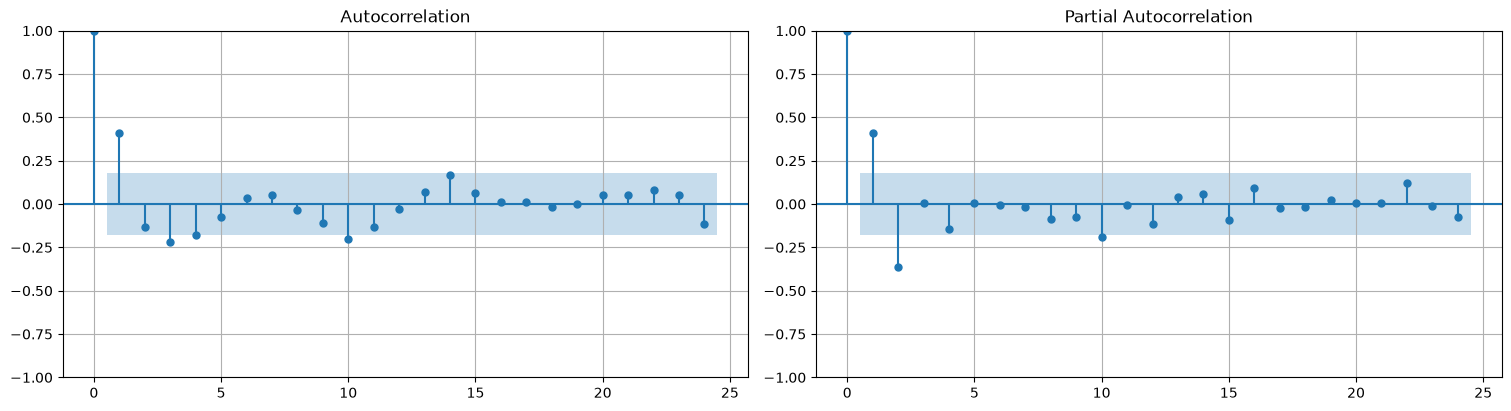

In [7]:
res_tr = fit_reg.resid
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(res_tr, lags=24, bartlett_confint=False, ax=axs[0])
plot_pacf(res_tr, lags=24, ax=axs[1]);

In [8]:
ordenes = [(1, 0, 0), (2, 0, 0), (1, 0, 1), (0, 0, 2)]
fits = {o: ARIMA(res_tr, order=o).fit() for o in ordenes}
aics = pd.Series({str(o): f.aic for o, f in fits.items()}).sort_values()
print(aics)

m_res = sorted(fits.values(), key=lambda f: f.aic)[0]
print()
print(f'Elegido: ARMA{m_res.model.order}')
print(m_res.summary().tables[1])
print()
print(sm.stats.acorr_ljungbox(m_res.resid, lags=[12]))

# MSE del modelo combinado (regresión + ARMA) dentro del train
ajuste_combinado = fit_reg.fittedvalues + m_res.fittedvalues
mse_train = ((df_tr['y'] - ajuste_combinado)**2).mean()
print()
print(f'MSE (train, escala log) del modelo combinado: {mse_train:.4f}')

(0, 0, 2)   -146.537830
(1, 0, 1)   -146.537481
(2, 0, 0)   -146.200791
(1, 0, 0)   -125.495893
dtype: float64

Elegido: ARMA(0, 0, 2)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0031      0.024      0.132      0.895      -0.043       0.050
ma.L1          0.7327      0.064     11.395      0.000       0.607       0.859
ma.L2          0.0038      0.095      0.040      0.968      -0.183       0.190
sigma2         0.0160      0.001     13.018      0.000       0.014       0.018

      lb_stat  lb_pvalue
12  10.105705   0.606688

MSE (train, escala log) del modelo combinado: 0.0167


**💬 Discusión 1.4** — Los residuos de la regresión muestran **autocorrelación de corto plazo** en la ACF/PACF → sí es modelable con un ARMA de orden bajo. En esta corrida el AIC favoreció un **MA(2)** (correlación que se corta tras 2 lags). Ljung-Box sobre los residuos del ARMA no rechaza ruido blanco: la combinación regresión (tendencia + estacionalidad) + ARMA (dependencia de corto plazo) captura la estructura. Reportamos también el MSE del ajuste combinado en el train.

### 1.5 Predicción completa 1979–1980 con `fit.append`

In [9]:
# Residuos del test respecto de la regresión (1978): observado - predicho por la regresión
pred_reg_te = fit_reg.predict(df_te)
res_te = df_te['y'] - pred_reg_te

# append: incorpora los residuos de 1978 al ARMA sin reestimar -> la predicción arranca en 1979
m_res_full = m_res.append(res_te)
pred_res_fut = m_res_full.get_forecast(24).predicted_mean   # 1979 y 1980
print(pred_res_fut.head())
print(f'\nLa predicción de residuos arranca en: {pred_res_fut.index[0]}')

1979-01   -0.049114
1979-02    0.002870
1979-03    0.003141
1979-04    0.003141
1979-05    0.003141
Freq: M, Name: predicted_mean, dtype: float64

La predicción de residuos arranca en: 1979-01


**💬 Discusión 1.5** — `fit.append(datos_nuevos)` agrega las observaciones del test al modelo **sin reestimar los parámetros**: el filtro avanza sobre 1978 y la predicción *completa* para 1979–1980 parte del último dato real. Es la forma correcta de predecir hacia adelante cuando apareció información nueva después del ajuste.

### 1.6 Predicción combinada en las variables originales

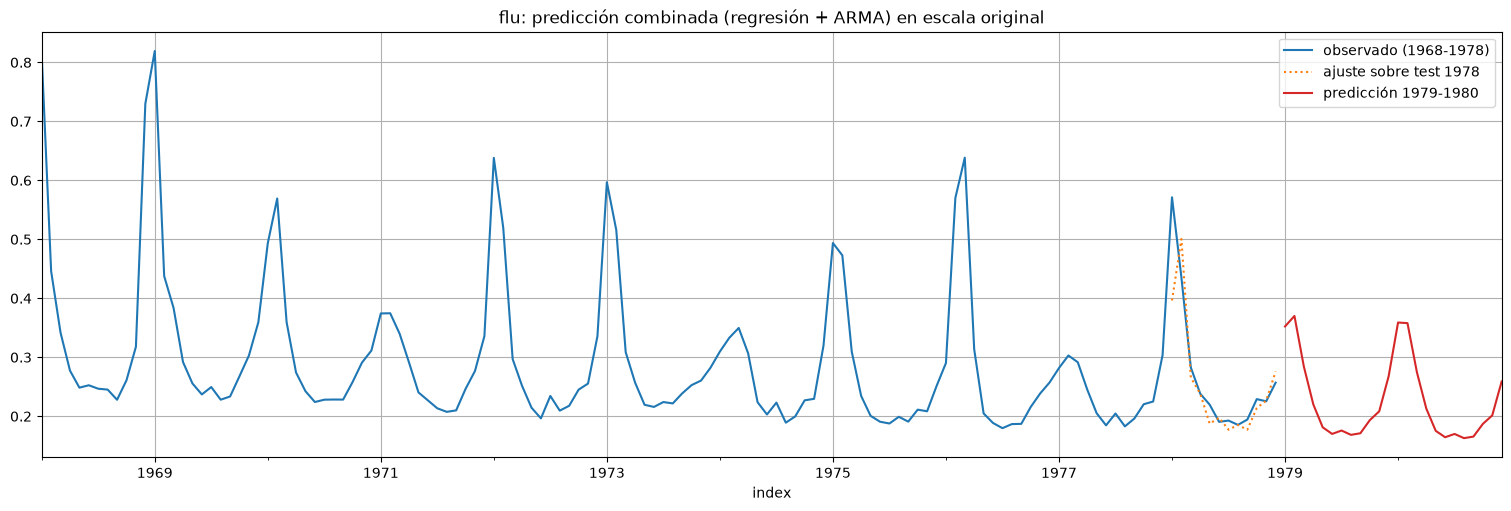

In [10]:
# Parte de regresión para 1979-1980: construir el dataframe futuro (t, mes y dummies)
idx_fut = pd.period_range('1979-01', periods=24, freq='M')
df_fut = pd.DataFrame({'t': np.arange(n, n + 24), 'mes': idx_fut.month}, index=idx_fut)
dum_fut = pd.get_dummies(df_fut['mes'], prefix='m', drop_first=True).astype(int)
df_fut = pd.concat([df_fut, dum_fut], axis=1)

pred_reg_fut = fit_reg.predict(df_fut)

# Combinar (escala log) y deshacer el cambio de variable
pred_log = pred_reg_fut + pred_res_fut
pred_final = np.exp(pred_log)

ax = flu.plot(label='observado (1968-1978)')
np.exp(pred_reg_te + m_res_full.predict(start=res_te.index[0], end=res_te.index[-1])).plot(ax=ax, label='ajuste sobre test 1978', style=':')
pred_final.plot(ax=ax, label='predicción 1979-1980', color='C3')
ax.legend()
ax.set_title('flu: predicción combinada (regresión + ARMA) en escala original');

**💬 Discusión 1.6** — La predicción combinada suma la parte determinística (tendencia + estacionalidad de la regresión) y la parte estocástica (ARMA de los residuos vía `append`), y se lleva a la escala original con `np.exp`. Reproduce el patrón estacional con picos de invierno y nivel decreciente. Nota: la parte ARMA se apaga geométricamente, así que hacia fines de 1980 la predicción es esencialmente la regresión.

---
## Ejercicio 2 — `climhyd`: cobertura nubosa e Inflow (Tipo A + Tipo C)

Series mensuales del Lago Shasta (índice sin fechas: RangeIndex). (1) análisis por frecuencias, (2) tendencia + frecuencias significativas, (3) residuos, (4) log(Inflow) + CCF + modelo con lag.

### 2.1 Análisis por frecuencias

,Frecuencia,Potencia
0,0.000000,0.828100
1,1.004405,0.060420
2,0.977974,0.003592
3,2.008811,0.001675
4,1.083700,0.001010
5,1.030837,0.001005


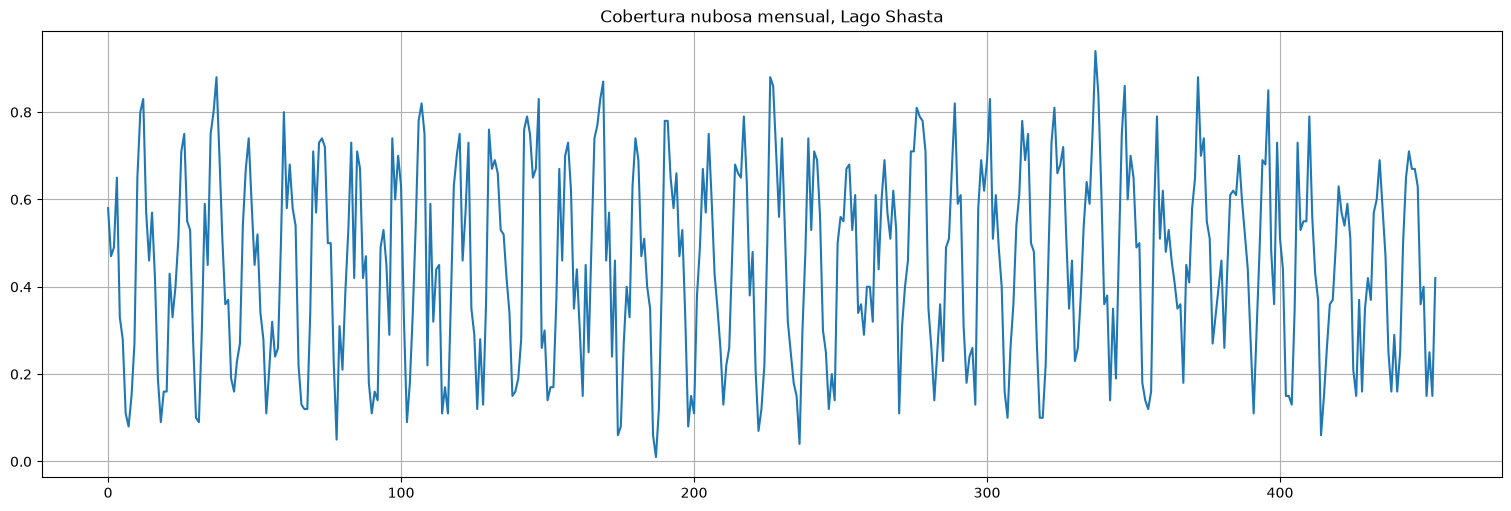

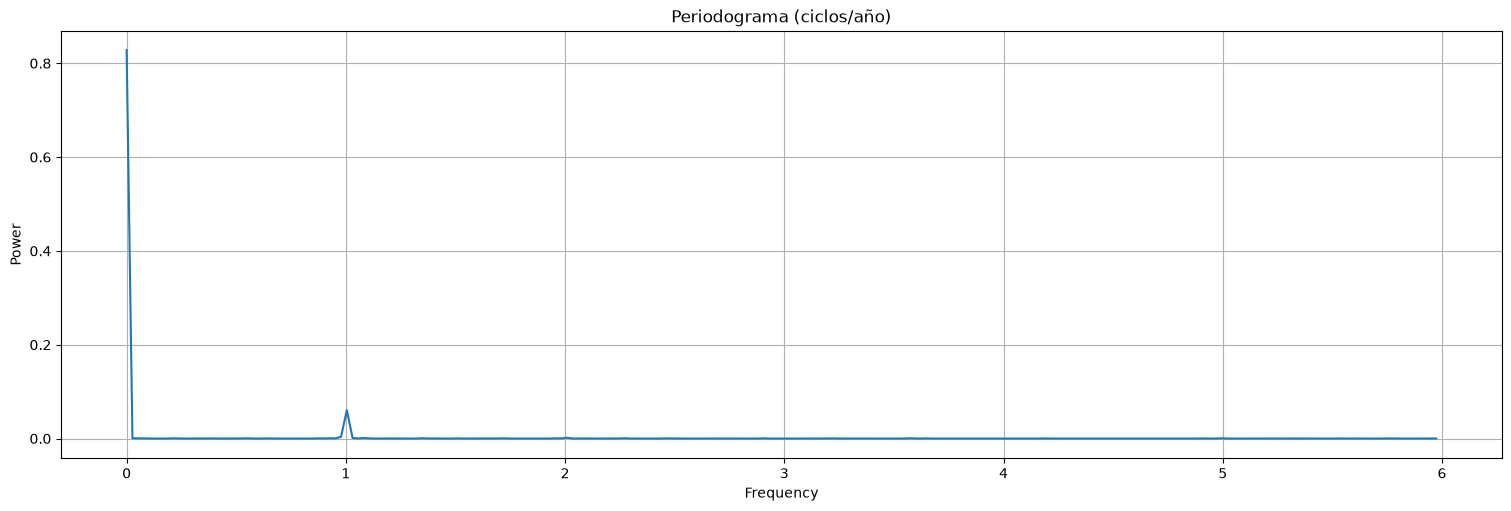

In [11]:
cloud = astsa.climhyd['CldCvr']
cloud.plot(title='Cobertura nubosa mensual, Lago Shasta')
plt.figure()
periodogram(cloud, sampling_frequency=12)
plt.title('Periodograma (ciclos/año)')
spectrum(cloud, sampling_frequency=12, nfreq=6)

**💬 Discusión 2.1** — El periodograma tiene un **pico dominante en f = 1 ciclo/año** (período 12 meses: el ciclo climático anual). Los demás picos son menores; si el armónico f = 2 aparece con potencia apreciable, se incluye también y se testea su significancia.

### 2.2 Tendencia lineal + frecuencias; eliminar no significativas

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4349      0.011     41.011      0.000       0.414       0.456
t           9.156e-05   4.05e-05      2.259      0.024    1.19e-05       0.000
sin1           0.0692      0.008      9.214      0.000       0.054       0.084
cos1           0.2497      0.008     33.243      0.000       0.235       0.264
sin2          -0.0381      0.008     -5.065      0.000      -0.053      -0.023
cos2          -0.0275      0.008     -3.667      0.000      -0.042      -0.013

Términos retenidos: ['t', 'sin1', 'cos1', 'sin2', 'cos2']
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4349      0.011     41.011      0.000       0.414       0.456
t           9.156e-05   4.05e-05      2.259      0.024    1.19e-05      

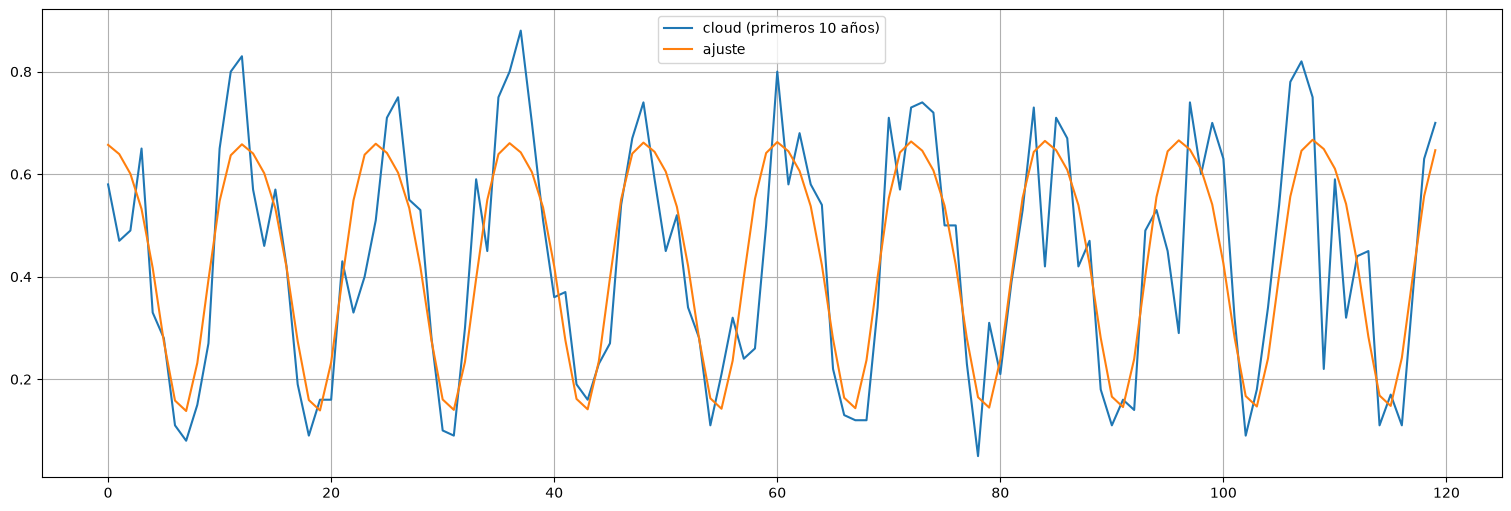

In [12]:
n2 = len(cloud)
dfc = pd.DataFrame({'y': cloud.values, 't': np.arange(n2)})
dfc['sin1'] = np.sin(2*np.pi*dfc['t']/12)
dfc['cos1'] = np.cos(2*np.pi*dfc['t']/12)
dfc['sin2'] = np.sin(2*np.pi*2*dfc['t']/12)
dfc['cos2'] = np.cos(2*np.pi*2*dfc['t']/12)

terminos = ['t', 'sin1', 'cos1', 'sin2', 'cos2']
f_all = ols('y ~ ' + ' + '.join(terminos), data=dfc).fit()
print(f_all.summary().tables[1])

keep = [c for c in terminos if f_all.pvalues[c] < 0.05]
print()
print('Términos retenidos:', keep)
fit_cloud = ols('y ~ ' + ' + '.join(keep), data=dfc).fit()
print(fit_cloud.summary().tables[1])
print()
print(f'R2 = {fit_cloud.rsquared:.3f}')

ax = cloud[:120].plot(label='cloud (primeros 10 años)')
pd.Series(fit_cloud.fittedvalues.values, index=cloud.index)[:120].plot(ax=ax, label='ajuste')
ax.legend();

**💬 Discusión 2.2** — Se ajusta tendencia + armónicos y se **eliminan los términos no significativos** (lo pide el enunciado; reportar cuáles quedaron). El ciclo anual (sin1/cos1) es lo esencial; la tendencia y el armónico semestral quedan solo si sus p-valores lo justifican.

### 2.3 Residuos del ajuste

      lb_stat  lb_pvalue
12  19.682567   0.073334
24  29.329946   0.207960


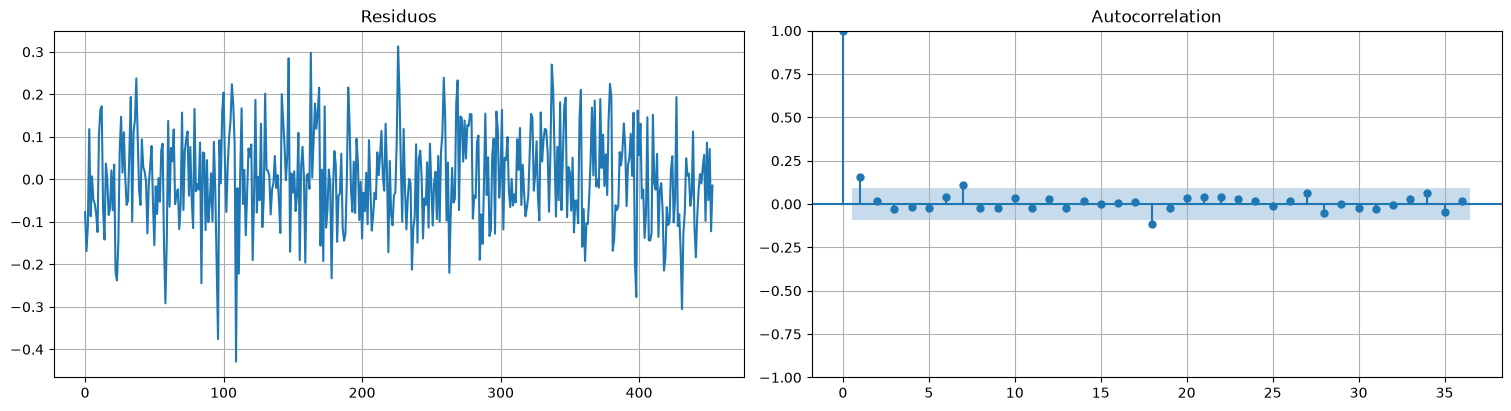

In [13]:
res_c = fit_cloud.resid
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
res_c.plot(ax=axs[0], title='Residuos')
plot_acf(res_c, lags=36, bartlett_confint=False, ax=axs[1])
print(sm.stats.acorr_ljungbox(res_c, lags=[12, 24]))

**💬 Discusión 2.3** — Ver la ACF: si queda correlación de corto plazo o restos de estacionalidad, decirlo ("queda información; podría modelarse con ARMA") — el enunciado aclara que no hay que seguir ajustando.

### 2.4 log(Inflow) + CCF + modelo con lag

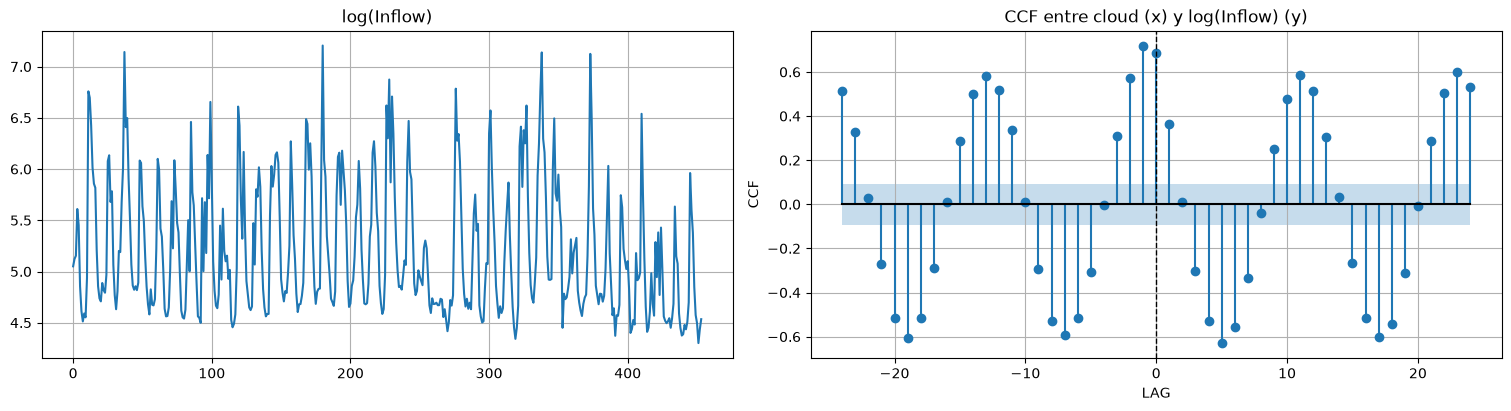

In [14]:
linf = np.log(astsa.climhyd['Inflow'])
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
linf.plot(ax=axs[0], title='log(Inflow)')
ccf(cloud, linf, max_lag=24, ax=axs[1])
axs[1].set_title('CCF entre cloud (x) y log(Inflow) (y)');

0     0.685434
1     0.719720
2     0.571699
3     0.308735
4    -0.001987
5    -0.306616
6    -0.519763
7    -0.599186
8    -0.534897
9    -0.297719
10    0.012156
11    0.344730
12    0.529250
dtype: float64

Lag más significativo: l = 1 | corr = 0.720

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2623      0.048     88.905      0.000       4.168       4.357
xlag           2.0917      0.095     22.015      0.000       1.905       2.278

R2 = 0.518


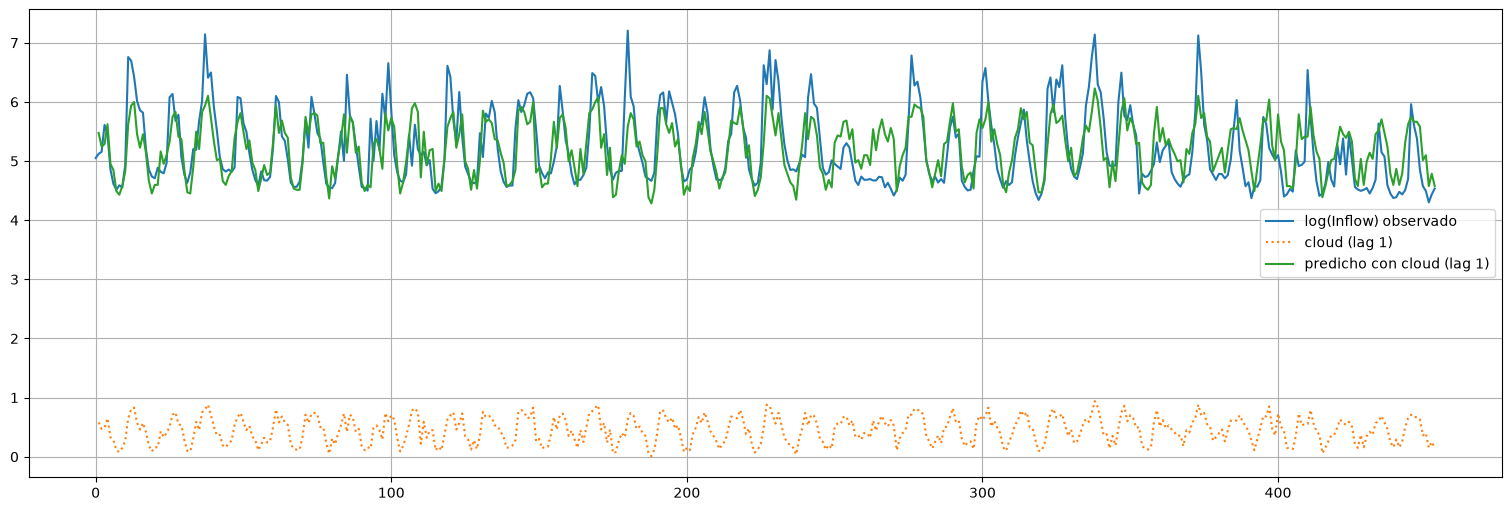

In [20]:
cors = pd.Series({l: linf.corr(cloud.shift(l)) for l in range(0, 13)})
print(cors)
l_opt = int(cors.abs().idxmax())
print()
print(f'Lag más significativo: l = {l_opt} | corr = {cors[l_opt]:.3f}')

datos = pd.DataFrame({'y': linf, 'xlag': cloud.shift(l_opt)}).dropna()
fit_inf = ols('y ~ xlag', data=datos).fit()
print()
print(fit_inf.summary().tables[1])
print()
print(f'R2 = {fit_inf.rsquared:.3f}')

ax = linf.plot(label='log(Inflow) observado')
cloud.shift(l_opt).plot(ax=ax, label=f'cloud (lag {l_opt})', style=':')
fit_inf.fittedvalues.plot(ax=ax, label=f'predicho con cloud (lag {l_opt})')
ax.legend();

In [23]:
print(fit_inf.fittedvalues-cloud.shift(l_opt)*2.09)



0           NaN
1      4.263266
2      4.263081
3      4.263114
4      4.263384
         ...   
449    4.262896
450    4.262963
451    4.262542
452    4.262711
453    4.262542
Length: 454, dtype: float64


**💬 Discusión 2.4** — Ambas series comparten el ciclo anual, por eso la CCF muestra ondas; el lag con mayor correlación (impreso arriba) define el modelo propuesto: log(Inflow)_t = β₀ + β₁·cloud_{t−l}. La nubosidad (lluvia) precede/acompaña al aporte de agua al lago. Reportar β₁ (positivo, significativo) y el R².

---
## Ejercicio 3 — COVID Uruguay: espacio de estados (`UnobservedComponents`) (Tipo D)

Casos diarios de COVID-19 en Uruguay. (1) modelo estructural con `level=True`, `stochastic_level=True`, `stochastic_seasonal=True`, `seasonal=7`; (2) graficar tendencia central y componente estacional.

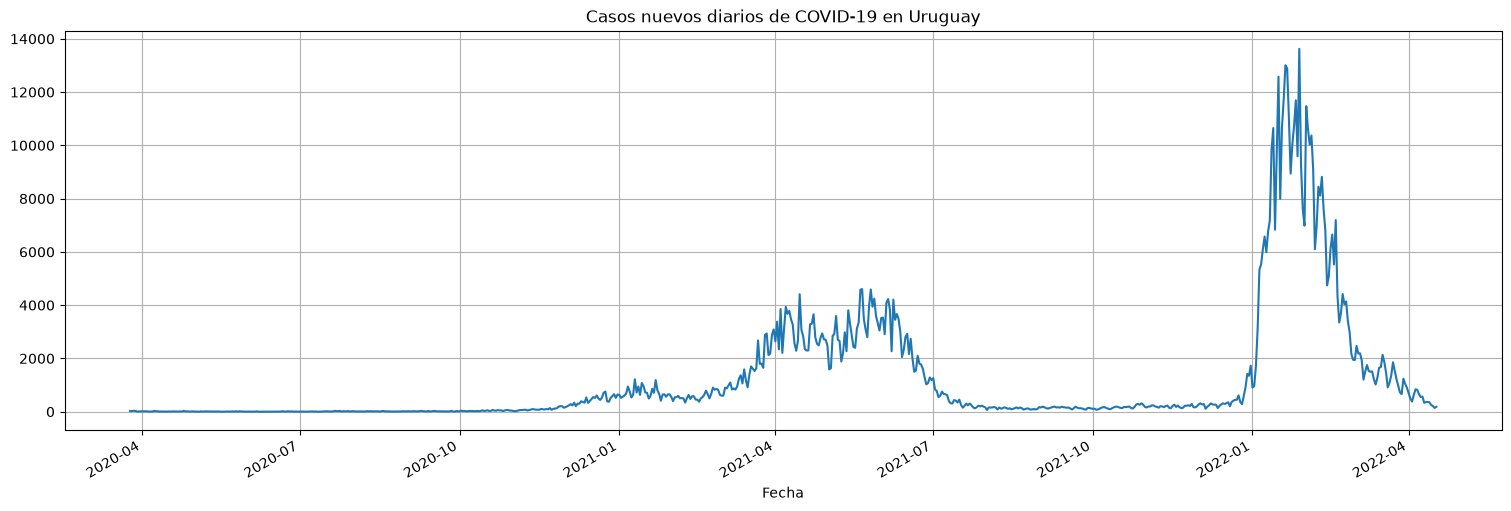

In [16]:
url = 'https://raw.githubusercontent.com/GUIAD-COVID/datos-y-visualizaciones-GUIAD/master/datos/estadisticasUY.csv'
local = 'data_covid_uy.csv'
try:
    data = pd.read_csv(local, index_col=[0], parse_dates=[0], date_format='%d/%m/%Y')
except FileNotFoundError:
    data = pd.read_csv(url, index_col=[0], parse_dates=[0], date_format='%d/%m/%Y')
    data.to_csv(local)   # cache local para estudiar sin internet

casos = data['cantCasosNuevosAjustado'].dropna()
casos.plot(xlabel='Fecha', title='Casos nuevos diarios de COVID-19 en Uruguay');

### 3.1 Modelo estructural

In [17]:
mod_uc = sm.tsa.UnobservedComponents(casos,
                                     level=True,
                                     stochastic_level=True,
                                     seasonal=7,
                                     stochastic_seasonal=True)
res_uc = mod_uc.fit()
print(res_uc.summary().tables[1])

c:\Users\joaco\anaconda3\envs\apst\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
sigma2.level     8.021e+04   2084.107     38.487      0.000    7.61e+04    8.43e+04
sigma2.seasonal  5.792e+04   1787.361     32.404      0.000    5.44e+04    6.14e+04


### 3.2 Tendencia central y componente estacional

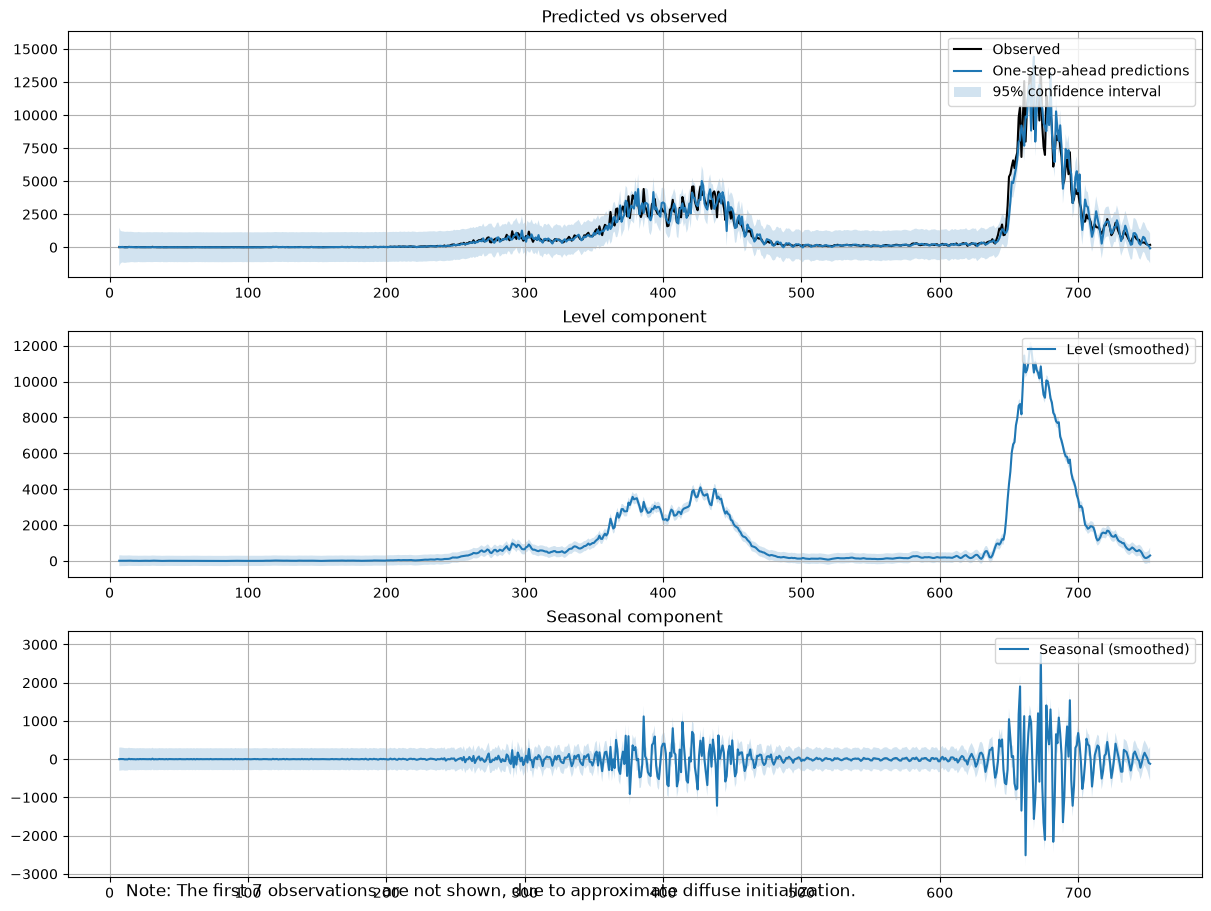

In [18]:
res_uc.plot_components(figsize=(12, 9));

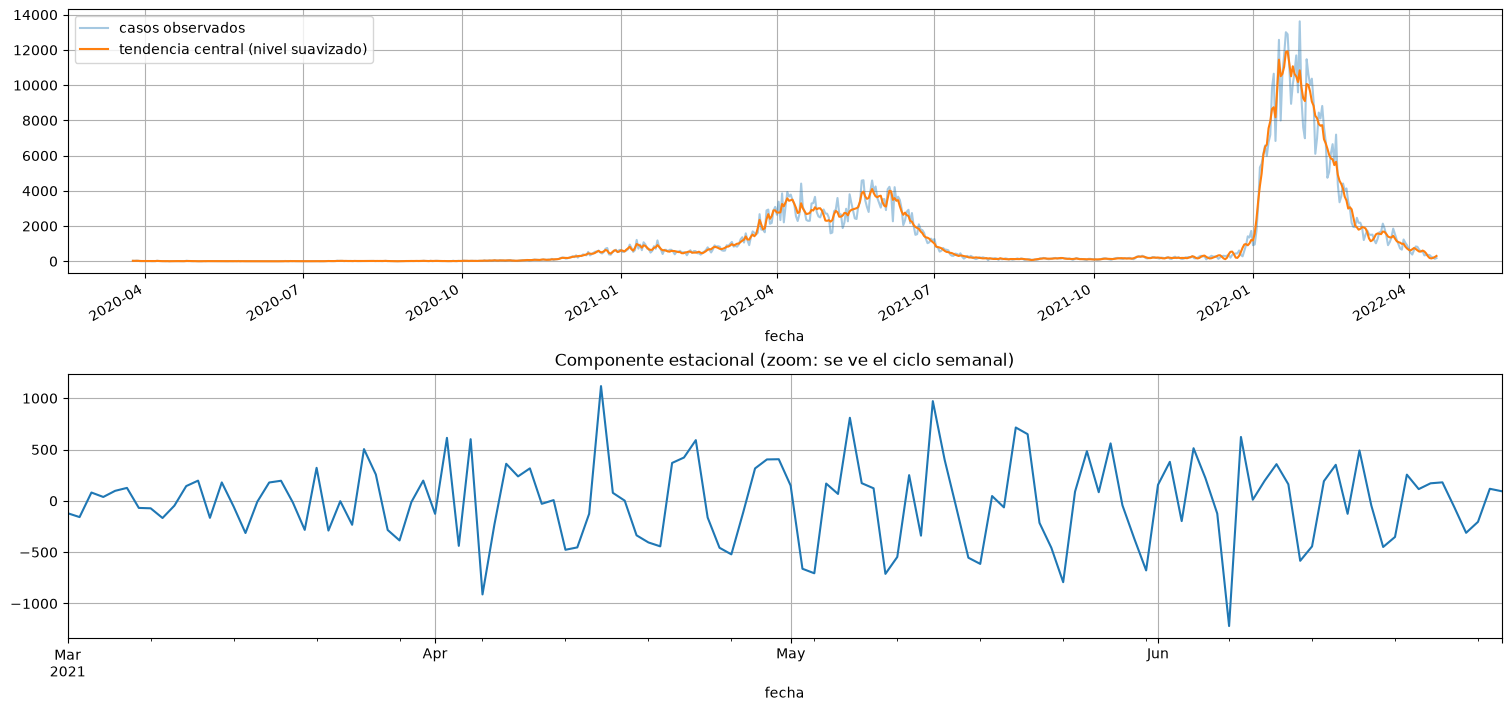

In [19]:
nivel = pd.Series(res_uc.level['smoothed'], index=casos.index)
estacional = pd.Series(res_uc.seasonal['smoothed'], index=casos.index)

fig, axs = plt.subplots(2, 1, figsize=(15, 7))
casos.plot(ax=axs[0], alpha=0.4, label='casos observados')
nivel.plot(ax=axs[0], label='tendencia central (nivel suavizado)', color='C1')
axs[0].legend()
estacional['2021-03':'2021-06'].plot(ax=axs[1], title='Componente estacional (zoom: se ve el ciclo semanal)');

**💬 Discusión 3** — Es un **modelo lineal dinámico (DLM)** estructural: el estado no observado (nivel + estacionalidad semanal) evoluciona en el tiempo y se estima con el **filtro de Kalman** (acá mostramos las componentes *suavizadas*, que usan toda la muestra). `stochastic_level=True` permite que la tendencia siga las olas de la pandemia; `stochastic_seasonal=True` deja que el patrón semanal (menos casos reportados los fines de semana) **cambie de amplitud** a lo largo del tiempo — se ve que la componente estacional crece cuando el nivel de casos es alto. Ventaja frente a la regresión clásica: no hay que especificar la forma de la tendencia; el modelo la aprende localmente.

---
## Moraleja del parcial 2024

- Ej. 1 es el **ejercicio integrador por excelencia**: log → regresión (tendencia + dummies significativas) → ARMA en residuos → `append` para el test → predicción combinada → `exp` para volver. Dominalo y tenés medio parcial.
- Ej. 2: mismo Tipo A pero **eligiendo frecuencias por periodograma** y filtrando por significancia; cierra con un mini Tipo C.
- Ej. 3: la receta `UnobservedComponents` — 4 argumentos y `plot_components()`. Saber QUÉ significa cada componente vale tanto como correrla.